In [2]:
import torch
import cv2
import numpy as np
import os
from ultralytics import YOLO
from torchvision import transforms
from PIL import Image
import timm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

e:\Tensorflow Kernel\tensorflow_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Load YOLO face detector
yolo_model = YOLO("path_to/FER_ViT/runs/detect/train7/weights/best.pt")

In [ ]:
# Load Vision Transformer
num_classes = 8   # same as training

vit_model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=False,
    num_classes=num_classes
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vit_model.load_state_dict(torch.load("path_to/FER_ViT/ViT_training/vit_fer_model.pth"))
vit_model = vit_model.to(device)
vit_model.eval()


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [6]:
emotion_classes = [
'Anger',
'Contempt',
'disgust',
'fear',
'happy',
'neutral',
'sad',
'surprise'
]

In [7]:
#Image Preprocessing for ViT
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [9]:
def crop_face_with_padding(image, box, padding=1.4):

    x1, y1, x2, y2 = map(int, box)

    h, w, _ = image.shape

    box_w = x2 - x1
    box_h = y2 - y1

    x1 = int(x1 - padding * box_w)
    y1 = int(y1 - padding * box_h)
    x2 = int(x2 + padding * box_w)
    y2 = int(y2 + padding * box_h)

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(w, x2)
    y2 = min(h, y2)

    face = image[y1:y2, x1:x2]

    return face

In [7]:
#FER Prediction Pipeline
def predict_emotion(image_path):

    image = cv2.imread(image_path)

    results = yolo_model(image)

    for result in results:

        boxes = result.boxes.xyxy.cpu().numpy()

        if len(boxes) == 0:
            return None

        # Select largest face
        largest_box = max(boxes, key=lambda b: (b[2]-b[0])*(b[3]-b[1]))

        face = crop_face_with_padding(image, largest_box)

        face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)

        face = Image.fromarray(face)

        face = transform(face).unsqueeze(0)

        face = face.to(next(vit_model.parameters()).device)

        with torch.no_grad():

            outputs = vit_model(face)

            pred = torch.argmax(outputs, dim=1).item()

        return pred

In [ ]:
image_path = "path_to/image1.png"

pred = predict_emotion(image_path)

print("Predicted Emotion:", emotion_classes[pred])


0: 256x256 1 face, 22.8ms
Speed: 0.0ms preprocess, 22.8ms inference, 152.9ms postprocess per image at shape (1, 3, 256, 256)


Predicted Emotion: neutral


In [ ]:
#Evaluate on Test Dataset
test_dir = "path_to/AffectNet/Test"

y_true = []
y_pred = []
y_prob = []

for label_idx, emotion in enumerate(emotion_classes):

    folder = os.path.join(test_dir, emotion)

    for img in os.listdir(folder):

        img_path = os.path.join(folder, img)

        image = cv2.imread(img_path)

        pred = predict_emotion(img_path)

        if pred is None:
            continue

        # run model again to get probabilities
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = Image.fromarray(image)

        image = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = vit_model(image)
            probs = torch.softmax(outputs, dim=1)

        y_true.append(label_idx)
        y_pred.append(torch.argmax(probs).item())
        y_prob.append(probs.cpu().numpy()[0])


0: 256x256 1 face, 21.1ms
Speed: 2.0ms preprocess, 21.1ms inference, 7.9ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 1 face, 16.4ms
Speed: 1.0ms preprocess, 16.4ms inference, 4.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 1 face, 18.3ms
Speed: 1.0ms preprocess, 18.3ms inference, 3.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 2 faces, 13.6ms
Speed: 1.0ms preprocess, 13.6ms inference, 2.5ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 3 faces, 15.9ms
Speed: 1.0ms preprocess, 15.9ms inference, 3.4ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 2 faces, 11.9ms
Speed: 2.0ms preprocess, 11.9ms inference, 3.2ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 2 faces, 17.3ms
Speed: 1.0ms preprocess, 17.3ms inference, 3.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 1 face, 14.9ms
Speed: 1.0ms preprocess, 14.9ms inference, 2.1ms postprocess per image at shape (1, 3, 256, 256)

0: 

In [11]:
#Calculate Evaluation Metrics
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=emotion_classes))

Accuracy: 0.6623592011609426
Precision: 0.675365847429965
Recall: 0.6623592011609426
F1 Score: 0.6452773674729969

Classification Report:

              precision    recall  f1-score   support

       Anger       0.68      0.37      0.48      1707
    Contempt       0.69      0.55      0.61      1307
     disgust       0.57      0.37      0.45      1240
        fear       0.70      0.39      0.50      1660
       happy       0.91      0.89      0.90      2704
     neutral       0.69      0.96      0.81      2368
         sad       0.53      0.97      0.68      1573
    surprise       0.47      0.49      0.48      1912

    accuracy                           0.66     14471
   macro avg       0.66      0.62      0.61     14471
weighted avg       0.68      0.66      0.65     14471



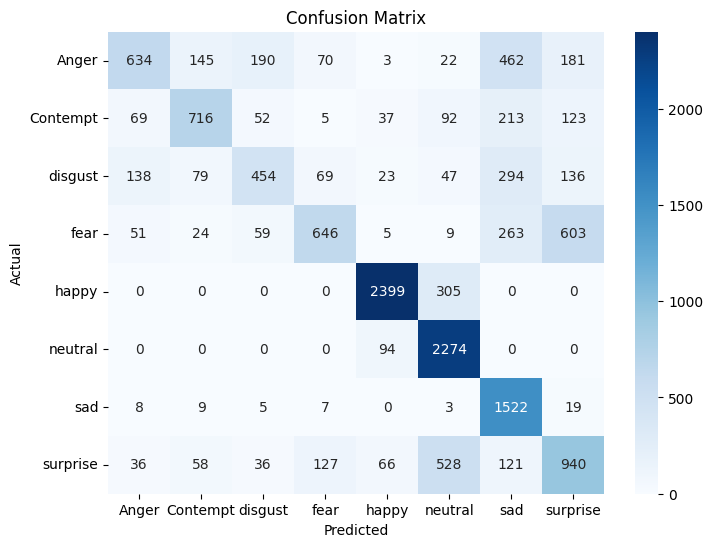

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=emotion_classes,
            yticklabels=emotion_classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

In [14]:
y_true = np.array(y_true)
y_prob = np.array(y_prob)

In [15]:
n_classes = len(emotion_classes)

y_true_bin = label_binarize(y_true, classes=range(n_classes))

In [16]:
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):

    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

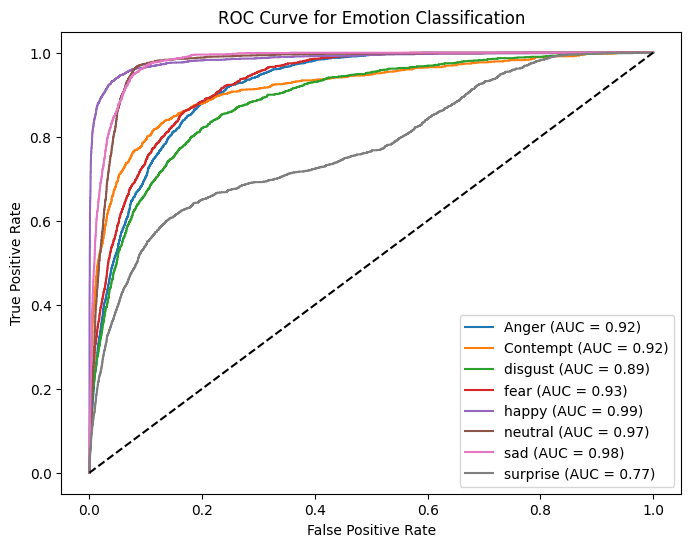

In [17]:
plt.figure(figsize=(8,6))

for i in range(n_classes):

    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{emotion_classes[i]} (AUC = {roc_auc[i]:.2f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Emotion Classification")

plt.legend()
plt.show()


0: 256x256 1 face, 19.8ms
Speed: 1.0ms preprocess, 19.8ms inference, 6.0ms postprocess per image at shape (1, 3, 256, 256)


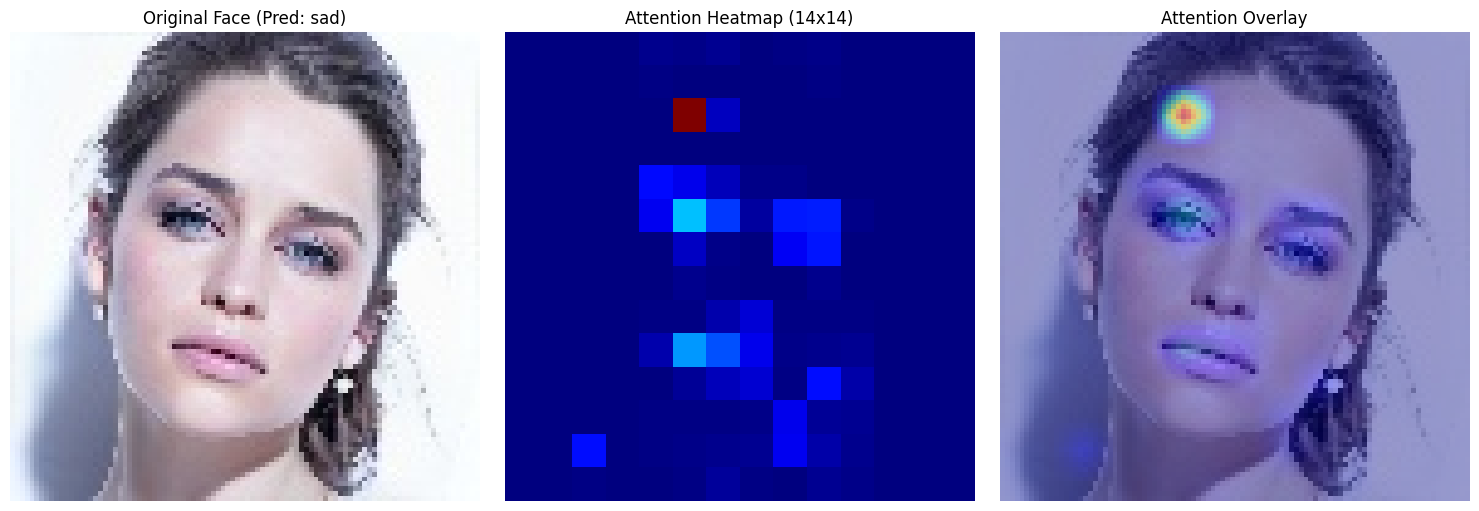

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch
from PIL import Image

# 1. Global variable and hook function to capture attention weights
attention_weights = None

def hook_fn(module, input, output):
    """
    Hook to capture the output of the qkv layer and calculate the attention matrix.
    For vit_base_patch16_224: num_heads=12, embed_dim=768.
    """
    global attention_weights
    # output of qkv layer has shape (batch, tokens, 3 * embed_dim)
    B, N, C = output.shape
    num_heads = 12 
    head_dim = C // (3 * num_heads)
    
    # Reshape and permute to separate Query, Key, and Value
    qkv = output.reshape(B, N, 3, num_heads, head_dim).permute(2, 0, 3, 1, 4)
    q, k, v = qkv[0], qkv[1], qkv[2]
    
    # Calculate attention matrix: (Softmax(Q @ K^T / sqrt(d_k)))
    attn = (q @ k.transpose(-2, -1)) * (head_dim ** -0.5)
    attn = attn.softmax(dim=-1)
    attention_weights = attn

# 2. Main function to generate and visualize the heatmap
def visualize_vit_attention(image_path, model, yolo, transform_fn, classes):
    model.eval()
    
    # Register the hook on the last block's attention qkv layer
    # Based on the notebook structure: model.blocks[-1].attn.qkv
    handle = model.blocks[-1].attn.qkv.register_forward_hook(hook_fn)
    
    # Detect face using YOLO (reusing your notebook's logic)
    image_bgr = cv2.imread(image_path)
    if image_bgr is None:
        print("Image not found.")
        return
        
    results = yolo(image_bgr)
    
    found_face = False
    for result in results:
        boxes = result.boxes.xyxy.cpu().numpy()
        if len(boxes) == 0: continue
        
        # Select largest face and crop (using your crop_face_with_padding function)
        largest_box = max(boxes, key=lambda b: (b[2]-b[0])*(b[3]-b[1]))
        face_crop = crop_face_with_padding(image_bgr, largest_box) # From Cell 6
        face_rgb = cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB)
        
        # Preprocess for ViT (using your transform from Cell 5)
        input_img = Image.fromarray(face_rgb)
        input_tensor = transform_fn(input_img).unsqueeze(0).to(device)
        
        # Forward pass to trigger the hook
        with torch.no_grad():
            output = model(input_tensor)
            pred_idx = torch.argmax(output, dim=1).item()
        
        # Process the captured attention_weights: (Batch, Heads, Tokens, Tokens)
        # Average attention across all 12 heads
        avg_attn = attention_weights.mean(dim=1) # Shape: (1, 197, 197)
        
        # Extract attention from the [CLS] token (index 0) to all image patches (indices 1 to 196)
        cls_attn = avg_attn[0, 0, 1:] # Shape: (196,)
        
        # Reshape to the 14x14 grid
        heatmap = cls_attn.reshape(14, 14).cpu().numpy()
        
        # Normalize and resize heatmap to the face crop dimensions
        heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())
        heatmap_resized = cv2.resize(heatmap, (face_rgb.shape[1], face_rgb.shape[0]))
        
        # Create a colored overlay
        heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
        overlay = cv2.addWeighted(face_rgb, 0.6, heatmap_color, 0.4, 0)
        
        # Display results
        plt.figure(figsize=(15, 5))
        plt.subplot(1, 3, 1)
        plt.title(f"Original Face (Pred: {classes[pred_idx]})")
        plt.imshow(face_rgb)
        plt.axis('off')
        
        plt.subplot(1, 3, 2)
        plt.title("Attention Heatmap (14x14)")
        plt.imshow(heatmap, cmap='jet')
        plt.axis('off')
        
        plt.subplot(1, 3, 3)
        plt.title("Attention Overlay")
        plt.imshow(overlay)
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
        
        found_face = True
        break # Only process the primary face detected
    
    if not found_face:
        print("No face detected by YOLO.")
    
    # Remove the hook to prevent memory leaks or interference with other cells
    handle.remove()

# 3. Execute visualization using existing variables from your notebook
# Replace with any valid image path
sample_path = "path_to/image1.jpg"

visualize_vit_attention(sample_path, vit_model, yolo_model, transform, emotion_classes)

In [ ]:
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

# 1. Define the path to your test/validation directory
# Based on your previous snippet, it looks like: "D:/AffectNet/Test"
test_data_path = "path_to/AffectNet/Test"

# 2. Create the Dataset using the transform we defined in Cell 5
test_dataset = ImageFolder(root=test_data_path, transform=transform)

# 3. Initialize the DataLoader
# batch_size=32 is usually safe, shuffle=True helps t-SNE see a mix of classes early
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

print(f"Loaded {len(test_dataset)} images from {len(test_dataset.classes)} classes.")

Loaded 14518 images from 8 classes.


Extracting features for t-SNE...
Running t-SNE on 1664 samples...


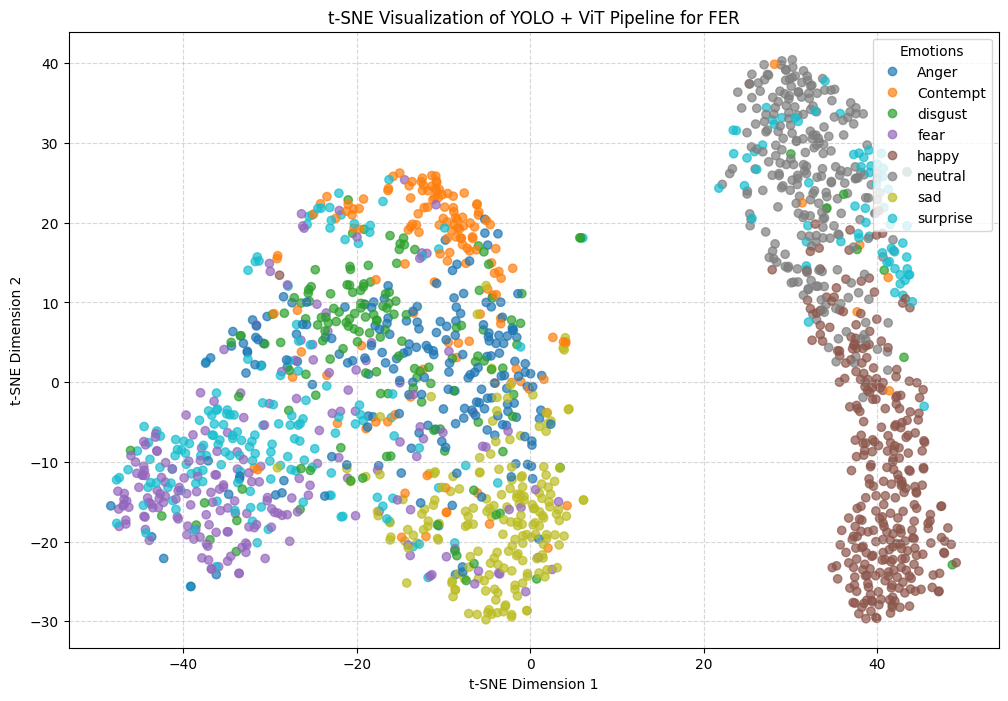

In [28]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_tsne(model, data_loader, device, classes):
    model.eval()
    features = []
    labels = []

    print("Extracting features for t-SNE...")
    with torch.no_grad():
        for i, (images, target) in enumerate(data_loader):
            images = images.to(device)
            
            # Extract features before the final classification head
            # For timm ViT: forward_features returns tokens (Batch, Tokens, Dim)
            # We take the CLS token (index 0)
            feat = model.forward_features(images)
            if isinstance(feat, torch.Tensor):
                # Some models return the tokens, others might return a pooled representation
                if feat.dim() == 3:
                    cls_token = feat[:, 0, :]
                else:
                    cls_token = feat
            else:
                cls_token = feat
                
            features.append(cls_token.cpu().numpy())
            labels.append(target.numpy())
            
            # Limit samples if dataset is very large (optional)
            if i > 50: 
                break

    features = np.concatenate(features, axis=0)
    labels = np.concatenate(labels, axis=0)

    print(f"Running t-SNE on {features.shape[0]} samples...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')
    tsne_results = tsne.fit_transform(features)

    # Visualization
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=labels, cmap='tab10', alpha=0.7)
    
    # Add a legend with class names
    legend1 = plt.legend(*scatter.legend_elements(), title="Emotions", loc="upper right")
    
    # Map class indices to names in legend
    for i, text in enumerate(legend1.get_texts()):
        idx = int(text.get_text().split('{')[-1].split('}')[0])
        text.set_text(classes[idx])

    plt.title("t-SNE Visualization of YOLO + ViT Pipeline for FER")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# Run the t-SNE visualization
# Using the test_loader and variables defined earlier in your notebook
plot_tsne(vit_model, test_loader, device, emotion_classes)